In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import scipy.stats as scp
from optbinning import OptimalBinning

In [2]:
import os

file_pulito = os.path.join('./data','dati_base.csv')
df = pd.read_csv(file_pulito)

In [3]:
pd.set_option('display.max_colwidth', 1000)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

In [4]:
df.head()

,origin_port,3pl,customs_procedures,logistic_hub,customer,units,late_order,weight,material_handling,dist_port_to_hub,...,dist_port_to_customer_direct,distance,total_weight,has_hub,weight_bin,distance_bin,units_bin,total_weight_bin,product_id,order_id
0,Rotterdam,v_002,DTP,Venlo,Marseille,583,1,1778.000,5.000,130.046,...,961.635,1032.088,1036574.000,1,5 - Elevato,3 - Medio Raggio,3 - Q,3 - Q,1692723,366c7a3d298f
1,Rotterdam,v_004,CRF,Rome,Marseille,459,0,1088.000,3.000,1269.236,...,961.635,1873.258,499392.000,1,3 - Basso,3 - Medio Raggio,1 - Q,2 - Q,1644308,45f906331e10
2,Athens,v_002,CRF,Venlo,Paris,464,1,505.000,4.000,2029.573,...,2101.294,2422.497,234320.000,1,2 - Lieve,4 - Lungo Raggio,1 - Q,2 - Q,1684170,ac84a6e4af0f
3,Rotterdam,v_004,CRF,Lille,Milan,678,0,1308.000,4.000,173.964,...,797.351,907.843,886824.000,1,4 - Standard,2 - Raggiungibile,4 - Q,2 - Q,1620510,f5e98cb29790
4,Barcelona,v_002,CRF,Venlo,Berlin,353,0,1465.000,0.000,1153.418,...,1499.697,1666.237,517145.000,1,4 - Standard,3 - Medio Raggio,1 - Q,2 - Q,1699372,a9e7c9bee35b


In [5]:
df.isnull().sum()

origin_port                        0
3pl                                0
customs_procedures                 0
logistic_hub                    1049
customer                           0
units                              0
late_order                         0
weight                             0
material_handling                  0
dist_port_to_hub                1049
dist_hub_to_customer            1469
dist_port_to_customer_direct    1507
distance                           0
total_weight                       0
has_hub                            0
weight_bin                         0
distance_bin                       0
units_bin                          0
total_weight_bin                   0
product_id                         0
order_id                           0
dtype: int64

In [6]:
df = df.drop(columns=['logistic_hub', 'dist_port_to_hub', 'dist_hub_to_customer', 'dist_port_to_customer_direct', 'weight_bin', 'units_bin'])

In [7]:
from statsmodels import robust
x = df["units"]
median = x.median()
mad = robust.mad(x)

modified_z = 0.6745 * (x - median) / mad
outliers = df[abs(modified_z) > 3.5]
len(outliers)

123

In [8]:
x = df["units"]

median = x.median()
mad = robust.mad(x)

modified_z = 0.6745 * (x - median) / mad

df = df[abs(modified_z) <= 3.5]

In [9]:
from statsmodels import robust
x = df["total_weight"]
median = x.median()
mad = robust.mad(x)

modified_z = 0.6745 * (x - median) / mad
outliers = df[abs(modified_z) > 3.5]
len(outliers)

40

In [10]:
x = df["total_weight"]

median = x.median()
mad = robust.mad(x)

modified_z = 0.6745 * (x - median) / mad

df = df[abs(modified_z) <= 3.5]

In [11]:
colonne_categoriche = ['origin_port', '3pl', 'customs_procedures', 'customer', 'distance_bin', 'total_weight_bin']

df_log = pd.get_dummies(
    df,
    columns=colonne_categoriche,
    drop_first=True
)

print("\nPrime 5 righe del DataFrame con le variabili dummy:")
df_log.head()


Prime 5 righe del DataFrame con le variabili dummy:


,units,late_order,weight,material_handling,distance,total_weight,has_hub,product_id,order_id,origin_port_Barcelona,...,customer_Valencia,customer_Vienna,distance_bin_2 - Raggiungibile,distance_bin_3 - Medio Raggio,distance_bin_4 - Lungo Raggio,distance_bin_5 - Distante,distance_bin_6 - Estremo,total_weight_bin_2 - Q,total_weight_bin_3 - Q,total_weight_bin_4 - Q
0,583,1,1778.000,5.000,1032.088,1036574.000,1,1692723,366c7a3d298f,False,...,False,False,False,True,False,False,False,False,True,False
1,459,0,1088.000,3.000,1873.258,499392.000,1,1644308,45f906331e10,False,...,False,False,False,True,False,False,False,True,False,False
2,464,1,505.000,4.000,2422.497,234320.000,1,1684170,ac84a6e4af0f,False,...,False,False,False,False,True,False,False,True,False,False
3,678,0,1308.000,4.000,907.843,886824.000,1,1620510,f5e98cb29790,False,...,False,False,True,False,False,False,False,True,False,False
4,353,0,1465.000,0.000,1666.237,517145.000,1,1699372,a9e7c9bee35b,True,...,False,False,False,True,False,False,False,True,False,False


### Baseline Logistic Regression con dati completi ###

In [12]:
from sklearn.model_selection import train_test_split

X = df_log.drop(columns=['late_order', 'product_id', 'order_id'])
y = df_log['late_order']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression 
from sklearn.model_selection import cross_val_score 

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(random_state=42, solver='liblinear', max_iter=2000, class_weight='balanced'))
])

pipeline.fit(X_train, y_train)

y_pred_proba = pipeline.predict_proba(X_test)[:, 1]

print("Pipeline con dati completi Costruita con successo (Selezione L1):")
print(pipeline)

print("\nEsecuzione Cross-Validation a 5 fold sulla Pipeline...")
cv_pipeline_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='accuracy')

print(f"Accuracy Score Media (5-fold CV) della Pipeline: {cv_pipeline_scores.mean():.4f}")

Pipeline con dati completi Costruita con successo (Selezione L1):
Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    random_state=42, solver='liblinear'))])

Esecuzione Cross-Validation a 5 fold sulla Pipeline...
Accuracy Score Media (5-fold CV) della Pipeline: 0.7279


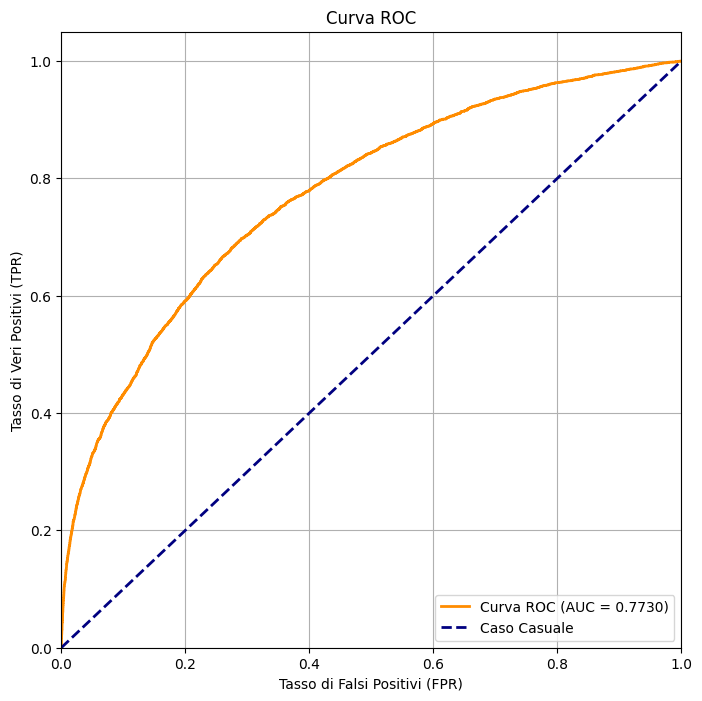

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Caso Casuale')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasso di Falsi Positivi (FPR)')
plt.ylabel('Tasso di Veri Positivi (TPR)')
plt.title('Curva ROC')
plt.legend(loc="lower right")
plt.grid(True)

In [15]:
# 1) Get the trained logistic regression model from pipeline
lr_model = pipeline.named_steps["model"]

# 2) Get feature names (after scaling, BEFORE the model)
feature_names = X_train.columns

# 3) Extract coefficients (1D array)
coefs = lr_model.coef_[0]

# 4) Build a dataframe of feature + importance
df_importance = pd.DataFrame({
    "feature": feature_names,
    "coef": coefs,
    "abs_coef": np.abs(coefs)         # importance = absolute value
})

# 5) Sort by strongest influence
df_importance = df_importance.sort_values("abs_coef", ascending=False)

print(df_importance.head(20))  # top 20 features

                      feature   coef  abs_coef
1                      weight -0.633     0.633
8                   3pl_v_002 -0.598     0.598
45     total_weight_bin_2 - Q -0.552     0.552
47     total_weight_bin_4 - Q  0.515     0.515
4                total_weight  0.462     0.462
7       origin_port_Rotterdam -0.455     0.455
10                  3pl_v_004 -0.373     0.373
12     customs_procedures_DTP  0.288     0.288
3                    distance  0.224     0.224
9                   3pl_v_003 -0.196     0.196
0                       units -0.191     0.191
11     customs_procedures_DTD  0.182     0.182
25              customer_Lyon  0.165     0.165
32             customer_Paris  0.165     0.165
6       origin_port_Barcelona -0.148     0.148
28         customer_Marseille  0.139     0.139
21        customer_Copenhagen  0.095     0.095
43  distance_bin_5 - Distante  0.095     0.095
16          customer_Bordeaux  0.086     0.086
44   distance_bin_6 - Estremo  0.080     0.080


In [16]:
import numpy as np
import pandas as pd
from scipy.stats import norm

# 1) Estrai modello e features dalla pipeline
model = pipeline.named_steps["model"]
scaler = pipeline.named_steps["scaler"]   
X_train_scaled = scaler.transform(X_train)

# 2) Predizioni delle probabilità
p = model.predict_proba(X_train_scaled)[:, 1]

# 3) Costruisci matrice X con intercetta
X_design = np.hstack([np.ones((X_train_scaled.shape[0], 1)), X_train_scaled])

# 4) Matrice W (p*(1-p))
W = np.diag(p * (1 - p))

# 5) Calcolo della matrice di informazione
Fisher_info = X_design.T @ W @ X_design

# 6) Inversa → varianze dei coefficienti
cov_matrix = np.linalg.inv(Fisher_info)

# 7) Deviazioni standard
std_err = np.sqrt(np.diag(cov_matrix))

# 8) Statistica Wald
params = np.hstack([model.intercept_, model.coef_[0]])
wald = params / std_err

# 9) p-values
p_values = 2 * (1 - norm.cdf(np.abs(wald)))

# 10) Output tabella
feature_names = ["intercept"] + list(X_train.columns)
df_pvalues = pd.DataFrame({
    "feature": feature_names,
    "coef": params,
    "std_err": std_err,
    "z_value": wald,
    "p_value": p_values
})

# Ordina per significatività
df_pvalues = df_pvalues.sort_values("p_value")

df_pvalues.head()

,feature,coef,std_err,z_value,p_value
0,intercept,-0.250,0.008,-32.023,0.000
46,total_weight_bin_2 - Q,-0.552,0.017,-33.150,0.000
33,customer_Paris,0.165,0.011,15.057,0.000
29,customer_Marseille,0.139,0.010,14.148,0.000
26,customer_Lyon,0.165,0.010,16.051,0.000


### Baseline Logistic Regression con dati binnizzati ###

In [17]:
df_bin = df_log.copy()

In [18]:
from sklearn.model_selection import train_test_split

X = df_bin.drop(columns=['late_order', 'product_id', 'order_id', 'units', 'late_order',	'weight', 'distance', 'total_weight'])
y = df_bin['late_order']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression 
from sklearn.model_selection import cross_val_score 

pipeline_bin = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(random_state=42, solver='liblinear', max_iter=2000, class_weight='balanced'))
])

pipeline_bin.fit(X_train, y_train)

y_pred_proba = pipeline_bin.predict_proba(X_test)[:, 1]

print("Pipeline con variabili binnizzate Costruita con successo (Selezione L1):")
print(pipeline_bin)

print("\nEsecuzione Cross-Validation a 5 fold sulla Pipeline...")
cv_pipeline_scores = cross_val_score(pipeline_bin, X_train, y_train, cv=5, scoring='accuracy')

print(f"Accuracy Score Media (5-fold CV) della Pipeline: {cv_pipeline_scores.mean():.4f}")

Pipeline con variabili binnizzate Costruita con successo (Selezione L1):
Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    random_state=42, solver='liblinear'))])

Esecuzione Cross-Validation a 5 fold sulla Pipeline...
Accuracy Score Media (5-fold CV) della Pipeline: 0.7258


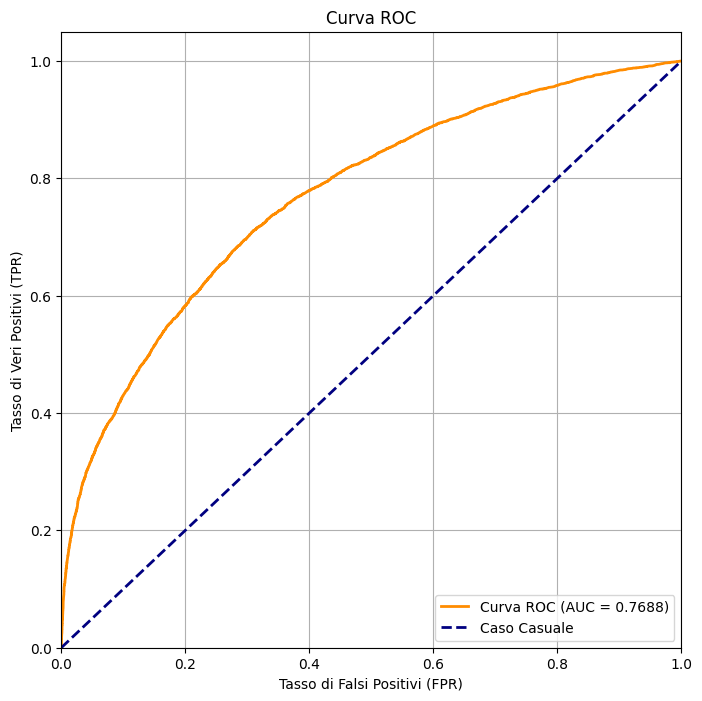

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Caso Casuale')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasso di Falsi Positivi (FPR)')
plt.ylabel('Tasso di Veri Positivi (TPR)')
plt.title('Curva ROC')
plt.legend(loc="lower right")
plt.grid(True)

In [21]:
# 1) Get the trained logistic regression model from pipeline
lr_model = pipeline_bin.named_steps["model"]

# 2) Get feature names (after scaling, BEFORE the model)
feature_names = X_train.columns

# 3) Extract coefficients (1D array)
coefs = lr_model.coef_[0]

# 4) Build a dataframe of feature + importance
df_importance = pd.DataFrame({
    "feature": feature_names,
    "coef": coefs,
    "abs_coef": np.abs(coefs)         # importance = absolute value
})

# 5) Filter ONLY binned variables
bin_features = df_importance[df_importance["feature"].str.contains("_bin")]

# 6) Sort by importance
bin_features_sorted = bin_features.sort_values("abs_coef", ascending=False)

print(bin_features_sorted)


                           feature   coef  abs_coef
41          total_weight_bin_2 - Q -0.697     0.697
43          total_weight_bin_4 - Q  0.363     0.363
39       distance_bin_5 - Distante  0.346     0.346
38   distance_bin_4 - Lungo Raggio  0.255     0.255
40        distance_bin_6 - Estremo  0.224     0.224
42          total_weight_bin_3 - Q -0.220     0.220
37   distance_bin_3 - Medio Raggio  0.189     0.189
36  distance_bin_2 - Raggiungibile  0.009     0.009


In [22]:
df_importance.sort_index()

,feature,coef,abs_coef
0,material_handling,-0.077,0.077
1,has_hub,-0.015,0.015
2,origin_port_Barcelona,-0.146,0.146
3,origin_port_Rotterdam,-0.461,0.461
4,3pl_v_002,-0.595,0.595
5,3pl_v_003,-0.195,0.195
6,3pl_v_004,-0.370,0.370
7,customs_procedures_DTD,0.182,0.182
8,customs_procedures_DTP,0.287,0.287
9,customer_Athens,0.075,0.075


In [23]:
import numpy as np
import pandas as pd
from scipy.stats import norm

# 1) Estrai modello e features dalla pipeline
model = pipeline_bin.named_steps["model"]
scaler = pipeline_bin.named_steps["scaler"]   
X_train_scaled = scaler.transform(X_train)

# 2) Predizioni delle probabilità
p = model.predict_proba(X_train_scaled)[:, 1]

# 3) Costruisci matrice X con intercetta
X_design = np.hstack([np.ones((X_train_scaled.shape[0], 1)), X_train_scaled])

# 4) Matrice W (p*(1-p))
W = np.diag(p * (1 - p))

# 5) Calcolo della matrice di informazione
Fisher_info = X_design.T @ W @ X_design

# 6) Inversa → varianze dei coefficienti
cov_matrix = np.linalg.inv(Fisher_info)

# 7) Deviazioni standard
std_err = np.sqrt(np.diag(cov_matrix))

# 8) Statistica Wald
params = np.hstack([model.intercept_, model.coef_[0]])
wald = params / std_err

# 9) p-values
p_values = 2 * (1 - norm.cdf(np.abs(wald)))

# 10) Output tabella
feature_names = ["intercept"] + list(X_train.columns)
df_pvalues = pd.DataFrame({
    "feature": feature_names,
    "coef": params,
    "std_err": std_err,
    "z_value": wald,
    "p_value": p_values
})

# Ordina per significatività
df_pvalues = df_pvalues.sort_values("p_value")

df_pvalues.head()

,feature,coef,std_err,z_value,p_value
0,intercept,-0.241,0.008,-30.976,0.000
42,total_weight_bin_2 - Q,-0.697,0.015,-47.909,0.000
41,distance_bin_6 - Estremo,0.224,0.010,22.393,0.000
40,distance_bin_5 - Distante,0.346,0.014,24.577,0.000
39,distance_bin_4 - Lungo Raggio,0.255,0.012,20.433,0.000


              precision    recall  f1-score   support

           0       0.87      0.74      0.80     17446
           1       0.44      0.65      0.52      5353

    accuracy                           0.72     22799
   macro avg       0.66      0.70      0.66     22799
weighted avg       0.77      0.72      0.74     22799



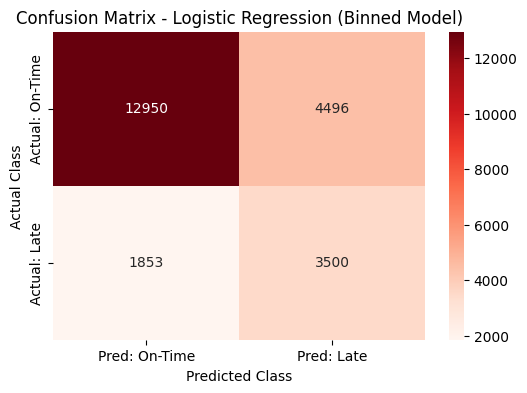

In [24]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = pipeline_bin.predict(X_test)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Reds',
            xticklabels=['Pred: On-Time', 'Pred: Late'],
            yticklabels=['Actual: On-Time', 'Actual: Late'])

plt.title("Confusion Matrix - Logistic Regression (Binned Model)")
plt.ylabel("Actual Class")
plt.xlabel("Predicted Class")
plt.show()

### Baseline Logistic Regression con variabili continue ###

In [25]:
df_cont = df.copy()

In [26]:
df_cont = df_cont.drop(columns=['distance_bin', 'total_weight_bin'])

In [27]:
colonne_categoriche = ['origin_port', '3pl', 'customs_procedures', 'customer']

df_cont = pd.get_dummies(
    df_cont,
    columns=colonne_categoriche,
    drop_first=True
)

print("\nPrime 5 righe del DataFrame con le variabili dummy:")
df_cont.head()


Prime 5 righe del DataFrame con le variabili dummy:


,units,late_order,weight,material_handling,distance,total_weight,has_hub,product_id,order_id,origin_port_Barcelona,...,customer_Munich,customer_Naples,customer_Paris,customer_Porto,customer_Prague,customer_Rome,customer_Stockholm,customer_Turin,customer_Valencia,customer_Vienna
0,583,1,1778.000,5.000,1032.088,1036574.000,1,1692723,366c7a3d298f,False,...,False,False,False,False,False,False,False,False,False,False
1,459,0,1088.000,3.000,1873.258,499392.000,1,1644308,45f906331e10,False,...,False,False,False,False,False,False,False,False,False,False
2,464,1,505.000,4.000,2422.497,234320.000,1,1684170,ac84a6e4af0f,False,...,False,False,True,False,False,False,False,False,False,False
3,678,0,1308.000,4.000,907.843,886824.000,1,1620510,f5e98cb29790,False,...,False,False,False,False,False,False,False,False,False,False
4,353,0,1465.000,0.000,1666.237,517145.000,1,1699372,a9e7c9bee35b,True,...,False,False,False,False,False,False,False,False,False,False


In [28]:
from sklearn.model_selection import train_test_split

X = df_cont.drop(columns=['late_order', 'product_id', 'order_id'])
y = df_cont['late_order']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression 
from sklearn.model_selection import cross_val_score 

pipeline_cont = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(random_state=42, solver='liblinear', max_iter=2000, class_weight='balanced'))
])

pipeline_cont.fit(X_train, y_train)

y_pred_proba = pipeline_cont.predict_proba(X_test)[:, 1]

print("Pipeline con variabili continute Costruita con successo (Selezione L1):")
print(pipeline_cont)

print("\nEsecuzione Cross-Validation a 5 fold sulla Pipeline...")
cv_pipeline_scores = cross_val_score(pipeline_cont, X_train, y_train, cv=5, scoring='accuracy')

print(f"Accuracy Score Media (5-fold CV) della Pipeline: {cv_pipeline_scores.mean():.4f}")

Pipeline con variabili continute Costruita con successo (Selezione L1):
Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    random_state=42, solver='liblinear'))])

Esecuzione Cross-Validation a 5 fold sulla Pipeline...
Accuracy Score Media (5-fold CV) della Pipeline: 0.6781


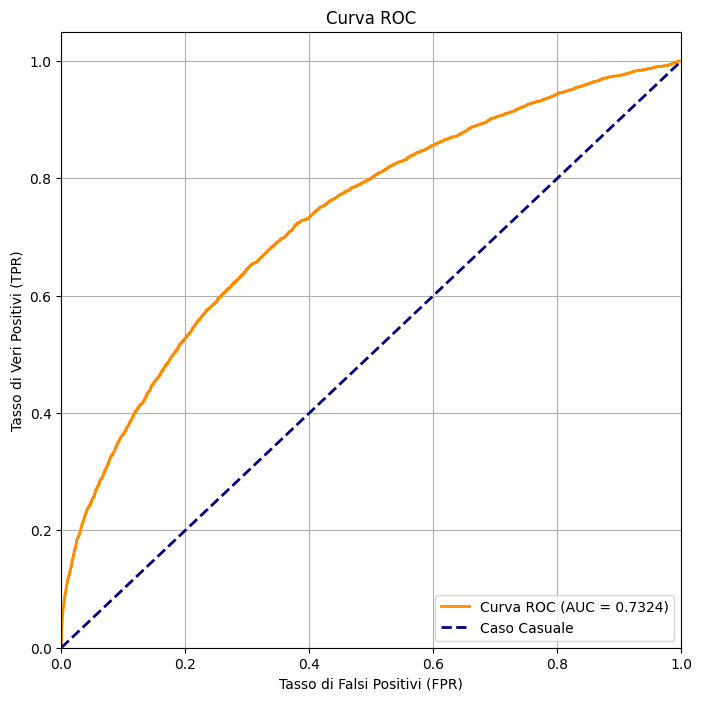

In [30]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Caso Casuale')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasso di Falsi Positivi (FPR)')
plt.ylabel('Tasso di Veri Positivi (TPR)')
plt.title('Curva ROC')
plt.legend(loc="lower right")
plt.grid(True)

In [31]:
# 1) Get the trained logistic regression model from pipeline
lr_model = pipeline_cont.named_steps["model"]

# 2) Get feature names (after scaling, BEFORE the model)
feature_names = X_train.columns

# 3) Extract coefficients (1D array)
coefs = lr_model.coef_[0]

# 4) Build a dataframe of feature + importance
df_importance = pd.DataFrame({
    "feature": feature_names,
    "coef": coefs,
    "abs_coef": np.abs(coefs)         # importance = absolute value
})

# 5) Sort by strongest influence
df_importance = df_importance.sort_values("abs_coef", ascending=False)

print(df_importance.head(20))  # top 20 features

                   feature   coef  abs_coef
4             total_weight  3.188     3.188
1                   weight -2.822     2.822
0                    units -0.866     0.866
8                3pl_v_002 -0.553     0.553
7    origin_port_Rotterdam -0.416     0.416
10               3pl_v_004 -0.350     0.350
3                 distance  0.291     0.291
12  customs_procedures_DTP  0.266     0.266
9                3pl_v_003 -0.183     0.183
11  customs_procedures_DTD  0.170     0.170
32          customer_Paris  0.153     0.153
25           customer_Lyon  0.151     0.151
6    origin_port_Barcelona -0.134     0.134
28      customer_Marseille  0.133     0.133
21     customer_Copenhagen  0.088     0.088
16       customer_Bordeaux  0.080     0.080
36      customer_Stockholm  0.073     0.073
13         customer_Athens  0.067     0.067
2        material_handling -0.066     0.066
23       customer_Helsinki  0.062     0.062


In [32]:
import numpy as np
import pandas as pd
from scipy.stats import norm

# 1) Estrai modello e features dalla pipeline
model = pipeline_cont.named_steps["model"]
scaler = pipeline_cont.named_steps["scaler"]   
X_train_scaled = scaler.transform(X_train)

# 2) Predizioni delle probabilità
p = model.predict_proba(X_train_scaled)[:, 1]

# 3) Costruisci matrice X con intercetta
X_design = np.hstack([np.ones((X_train_scaled.shape[0], 1)), X_train_scaled])

# 4) Matrice W (p*(1-p))
W = np.diag(p * (1 - p))

# 5) Calcolo della matrice di informazione
Fisher_info = X_design.T @ W @ X_design

# 6) Inversa → varianze dei coefficienti
cov_matrix = np.linalg.inv(Fisher_info)

# 7) Deviazioni standard
std_err = np.sqrt(np.diag(cov_matrix))

# 8) Statistica Wald
params = np.hstack([model.intercept_, model.coef_[0]])
wald = params / std_err

# 9) p-values
p_values = 2 * (1 - norm.cdf(np.abs(wald)))

# 10) Output tabella
feature_names = ["intercept"] + list(X_train.columns)
df_pvalues = pd.DataFrame({
    "feature": feature_names,
    "coef": params,
    "std_err": std_err,
    "z_value": wald,
    "p_value": p_values
})

# Ordina per significatività
df_pvalues = df_pvalues.sort_values("p_value")

df_pvalues.head()

,feature,coef,std_err,z_value,p_value
0,intercept,-0.195,0.007,-26.898,0.000
29,customer_Marseille,0.133,0.009,14.173,0.000
26,customer_Lyon,0.151,0.010,15.446,0.000
22,customer_Copenhagen,0.088,0.010,8.995,0.000
17,customer_Bordeaux,0.080,0.008,9.727,0.000


In [33]:
import os

file_outliers = os.path.join('./data','dati_outliers.csv')
df_out = pd.read_csv(file_outliers)

In [34]:
from sklearn.model_selection import train_test_split

# 1. Trasformiamo le colonne di testo in numeri (One-Hot Encoding) anche per df_out
# Usiamo le stesse colonne categoriche che hai usato prima
colonne_categoriche = ['origin_port', '3pl', 'customs_procedures', 'customer', 'logistic_hub', 'distance_bin', 'total_weight_bin', 'units_bin', 'weight_bin']

# Creiamo la versione numerica
df_out_encoded = pd.get_dummies(df_out, columns=colonne_categoriche, drop_first=True)

# 2. Ora possiamo definire X e y usando i dati numerici
# Nota: Rimuoviamo anche le colonne originali non più utili se sono rimaste, e gli ID
X = df_out_encoded.drop(columns=['late_order', 'product_id', 'order_id', 'units', 'distance', 'weight', 'total_weight', 'dist_port_to_hub', 'dist_hub_to_customer', 'dist_port_to_customer_direct'])
y = df_out_encoded['late_order']

# 3. Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Creazione del Modello
# n_estimators=100: crea 100 alberi (standard robusto)
# class_weight='balanced': Utile perché i tuoi ordini in ritardo sono meno di quelli puntuali
# random_state=42: per replicare i risultati
rf_model = RandomForestClassifier(n_estimators=500, 
                                  max_depth=15, 
                                  random_state=42, 
                                  class_weight='balanced')

# 2. Addestramento (Uso le variabili X_train e y_train che hai creato nella cella 86)
print("Addestramento Random Forest in corso...")
rf_model.fit(X_train, y_train)

# 3. Predizione
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1] # Serve per la ROC curve

# 4. Valutazione
print("\n--- Performance Random Forest ---")
acc = accuracy_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy: {acc:.4f}")
print(f"ROC-AUC:  {roc:.4f}")
print("\nReport di Classificazione:")
print(classification_report(y_test, y_pred))

Addestramento Random Forest in corso...

--- Performance Random Forest ---
Accuracy: 0.7639
ROC-AUC:  0.7943

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.87      0.81      0.84     17354
           1       0.51      0.62      0.56      5478

    accuracy                           0.76     22832
   macro avg       0.69      0.72      0.70     22832
weighted avg       0.78      0.76      0.77     22832



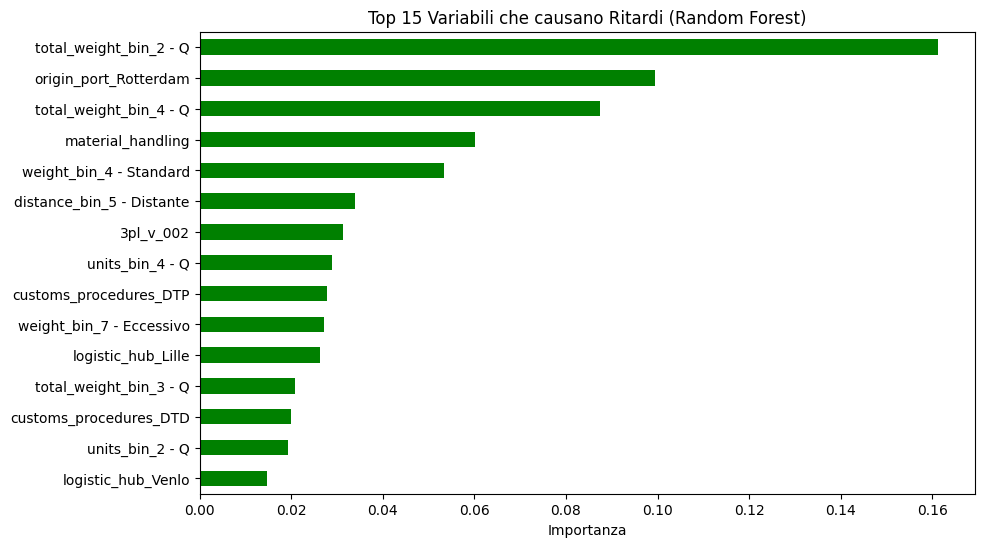

In [36]:
# Creazione dataframe importanza
importances = rf_model.feature_importances_
feature_names = X_train.columns
forest_importances = pd.Series(importances, index=feature_names)

# Ordina e prendi le top 15
top_features = forest_importances.sort_values(ascending=False).head(15)

# Grafico
plt.figure(figsize=(10, 6))
top_features.plot(kind='barh', color='green')
plt.title("Top 15 Variabili che causano Ritardi (Random Forest)")
plt.xlabel("Importanza")
plt.gca().invert_yaxis() # Inverte l'asse per avere la più importante in alto
plt.show()

In [37]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score

# 1. Definisci la griglia di parametri da provare
param_dist = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_iter': [100, 300, 500],        # Numero di alberi
    'max_leaf_nodes': [31, 63, 127],    # Complessità dell'albero
    'min_samples_leaf': [20, 50, 80],   # Prevenzione overfitting
    'l2_regularization': [0, 0.1, 1.0]  # Regolarizzazione
}

# 2. Configura il modello base
base_model = HistGradientBoostingClassifier(
    class_weight='balanced', 
    random_state=42,
    scoring='roc_auc'
)

# 3. Lancia la ricerca casuale (Random Search)
# n_iter=20: Proverà 20 combinazioni diverse
print("Inizio ottimizzazione parametri (attendere prego)...")
search = RandomizedSearchCV(
    base_model, 
    param_distributions=param_dist, 
    n_iter=20, 
    cv=3, 
    scoring='f1', # Ottimizza per F1-score (media tra precision e recall)
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

# 4. Risultati
print(f"\nI migliori parametri trovati: {search.best_params_}")

# 5. Valuta il modello migliore sul test set
best_model = search.best_estimator_
y_pred_opt = best_model.predict(X_test)
y_proba_opt = best_model.predict_proba(X_test)[:, 1]

print("\n--- Performance Modello Ottimizzato ---")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_opt):.4f}")
print(classification_report(y_test, y_pred_opt))

Inizio ottimizzazione parametri (attendere prego)...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

I migliori parametri trovati: {'min_samples_leaf': 20, 'max_leaf_nodes': 31, 'max_iter': 300, 'learning_rate': 0.05, 'l2_regularization': 0.1}

--- Performance Modello Ottimizzato ---
ROC-AUC: 0.8087
              precision    recall  f1-score   support

           0       0.89      0.75      0.81     17354
           1       0.47      0.71      0.57      5478

    accuracy                           0.74     22832
   macro avg       0.68      0.73      0.69     22832
weighted avg       0.79      0.74      0.75     22832



In [38]:
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score

# 1. Ottieni le probabilità dal modello migliore (o quello base se non hai fatto il tuning)
# Se hai usato il codice sopra, usa 'best_model', altrimenti 'hgb_model'
y_proba = best_model.predict_proba(X_test)[:, 1]

# 2. Cerca la soglia migliore
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = []

for thresh in thresholds:
    # Converti probabilità in 0 o 1 usando la soglia corrente
    y_pred_temp = (y_proba >= thresh).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_temp))

# 3. Trova il picco
best_thresh_idx = np.argmax(f1_scores)
best_thresh = thresholds[best_thresh_idx]
best_f1 = f1_scores[best_thresh_idx]

print(f"Soglia Ottimale trovata: {best_thresh:.2f}")
print(f"Miglior F1-Score possibile: {best_f1:.4f}")

# 4. Applica la nuova soglia
y_pred_final = (y_proba >= best_thresh).astype(int)

print("\n--- Report con Soglia Ottimizzata ---")
print(classification_report(y_test, y_pred_final))

Soglia Ottimale trovata: 0.53
Miglior F1-Score possibile: 0.5721

--- Report con Soglia Ottimizzata ---
              precision    recall  f1-score   support

           0       0.88      0.79      0.83     17354
           1       0.50      0.67      0.57      5478

    accuracy                           0.76     22832
   macro avg       0.69      0.73      0.70     22832
weighted avg       0.79      0.76      0.77     22832



In [39]:
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

# SGDClassifier con 'hinge' è praticamente una SVM lineare molto veloce
sgd_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('sgd', SGDClassifier(loss='hinge', # 'hinge' = comportamento SVM
                          class_weight='balanced', 
                          random_state=42,
                          max_iter=1000,
                          n_jobs=-1))
])

print("Addestramento SGD (SVM veloce)...")
sgd_pipeline.fit(X_train, y_train)
print(classification_report(y_test, sgd_pipeline.predict(X_test)))

Addestramento SGD (SVM veloce)...
              precision    recall  f1-score   support

           0       0.89      0.71      0.79     17354
           1       0.44      0.72      0.54      5478

    accuracy                           0.71     22832
   macro avg       0.66      0.71      0.66     22832
weighted avg       0.78      0.71      0.73     22832



Inizio ricerca dei migliori iperparametri (RandomizedSearchCV)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

✅ Migliori parametri trovati: {'model__colsample_bytree': np.float64(0.902144564127061), 'model__learning_rate': np.float64(0.09503117489824894), 'model__max_depth': 10, 'model__n_estimators': 205, 'model__num_leaves': 23, 'model__subsample': np.float64(0.6739417822102108)}
✅ Miglior AUC in validazione: 0.8171

🚀 L'AUC-ROC Score finale sul Test Set è: 0.8186
____________________________________________________________
Risultati con soglia: 0.45
🚀 Richiamo (Recall): 0.7596
Report completo:
              precision    recall  f1-score   support

           0       0.91      0.71      0.80     21743
           1       0.45      0.76      0.57      6756

    accuracy                           0.72     28499
   macro avg       0.68      0.74      0.68     28499
weighted avg       0.80      0.72      0.74     28499



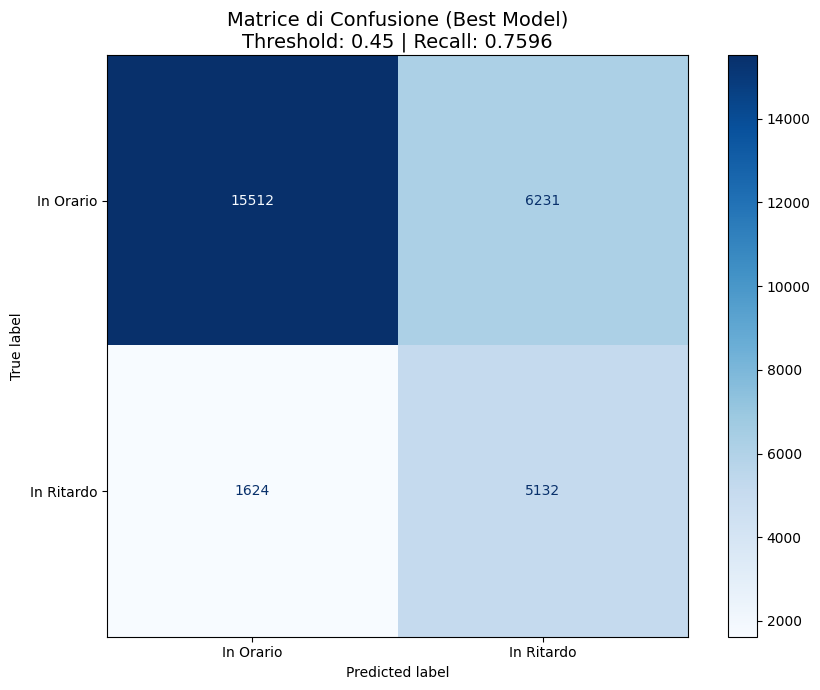

In [40]:
# ORA LGBMC MIGLIORATO CON LA GRIDSEARCH

from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import confusion_matrix, recall_score, roc_auc_score, ConfusionMatrixDisplay, classification_report
from sklearn.pipeline import Pipeline
from scipy.stats import randint, uniform

X_lgbm = df_log.drop(columns=['late_order', 'product_id', 'order_id'])
y_lgbm = df_log['late_order']

# --- 3. SPLIT ---
X_lgbm_train, X_lgbm_test, y_lgbm_train, y_lgbm_test = train_test_split(
    X_lgbm, y_lgbm, test_size=0.25, random_state=42, stratify=y_lgbm)


# --- 2. PIPELINE E RICERCA PARAMETRI (TUNING) ---

# Definiamo la pipeline (espandibile in futuro con scaler o imputer)
pipeline = Pipeline([
    ('model', LGBMClassifier(
        random_state=42, 
        n_jobs=-1, 
        class_weight='balanced',  # Fondamentale per il tuo sbilanciamento
        importance_type='gain',
        verbose=-1
    ))
])

# Definiamo lo spazio di ricerca dei parametri
# Nota: usiamo 'model__' come prefisso perché il modello si chiama 'model' nella pipeline
param_dist = {
    'model__n_estimators': randint(100, 1000),      # Numero di alberi
    'model__learning_rate': uniform(0.01, 0.2),     # Velocità
    'model__num_leaves': randint(20, 100),          # Complessità dell'albero
    'model__max_depth': [-1, 10, 20, 50],           # Profondità
    'model__subsample': uniform(0.6, 0.4),          # Per evitare overfitting
    'model__colsample_bytree': uniform(0.6, 0.4)    # Per evitare overfitting
}

print("Inizio ricerca dei migliori iperparametri (RandomizedSearchCV)...")

# Configurazione della Cross-Validation Stratificata
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Configurazione della ricerca
search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=20,              # Prova 20 combinazioni diverse (aumenta per risultati migliori)
    scoring='roc_auc',      # Ottimizziamo per AUC (buono per classi sbilanciate)
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Addestramento con ricerca
search.fit(X_lgbm_train, y_lgbm_train)

print(f"\n✅ Migliori parametri trovati: {search.best_params_}")
print(f"✅ Miglior AUC in validazione: {search.best_score_:.4f}")

# --- 3. VALUTAZIONE SUL TEST SET ---

# Estraiamo il modello migliore
best_model = search.best_estimator_

# Calcolo probabilità
y_lgbm_proba = best_model.predict_proba(X_lgbm_test)[:, 1]

# Calcolo AUC finale
auc_score = roc_auc_score(y_lgbm_test, y_lgbm_proba)
print(f"\n🚀 L'AUC-ROC Score finale sul Test Set è: {auc_score:.4f}")

# --- 4. GESTIONE SOGLIA PER FALSI NEGATIVI ---
# Qui sta il trucco: Non usare 0.5 se vuoi evitare i falsi negativi!
# Cerchiamo una soglia che ci dia un alto Recall mantenendo una precisione decente.
# Esempio: Impostiamo una soglia conservativa
soglia_personalizzata = 0.45 
# Se abbassi questo numero (es. 0.3), il Recall aumenterà (meno FN), ma aumenteranno i Falsi Positivi.

y_lgbm_pred_binaria = (y_lgbm_proba >= soglia_personalizzata).astype(int)

# --- 5. VISUALIZZAZIONE ---

# Matrice di confusione
cm_lgbm = confusion_matrix(y_lgbm_test, y_lgbm_pred_binaria)
recall_lgbm = recall_score(y_lgbm_test, y_lgbm_pred_binaria)

print('_'*60)
print(f"Risultati con soglia: {soglia_personalizzata}")
print(f"🚀 Richiamo (Recall): {recall_lgbm:.4f}")
print("Report completo:")
print(classification_report(y_lgbm_test, y_lgbm_pred_binaria))

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lgbm, display_labels=['In Orario', 'In Ritardo'])
fig, ax = plt.subplots(figsize=(9, 7))
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d') # 'd' per interi, niente notazione scientifica

ax.set_title(f'Matrice di Confusione (Best Model)\nThreshold: {soglia_personalizzata} | Recall: {recall_lgbm:.4f}', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
#  Feature Importance
# Accedere al modello dentro la pipeline è un po' diverso:
lgbm_model = best_model.named_steps['model']
feature_imp = pd.DataFrame(sorted(zip(lgbm_model.feature_importances_, X_lgbm.columns)), columns=['Value','Feature'])
print("\nTop 5 Feature più importanti:")
print(feature_imp.sort_values(by="Value", ascending=False).head(5))


Top 5 Feature più importanti:
       Value                 Feature
47 43491.914  total_weight_bin_2 - Q
46 33496.381                  weight
45 25124.504            total_weight
44 23216.123                distance
43 21324.441   origin_port_Rotterdam


: 